# LSTM Autoencoder

In [203]:
%run helperFunctions.ipynb

read: ./data/faulty\Circuit_Scenario1_batery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario1_switch1_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_empty_res.csv
read: ./data/faulty\Circuit_Scenario2_switch_2_broken_res.csv
read: ./data/faulty\Circuit_Scenario3_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario3_switch_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario4_switch_1_broken_res.csv
read: ./data/faultless\Circuit_Scenario1_res.csv
read: ./data/faultless\Circuit_Scenario2_res.csv
read: ./data/faultless\Circuit_Scenario3_res.csv
read: ./data/faultless\Circuit_Scenario4_res.csv


In [205]:
#parameters 
window_size = 6 
step_size = 1
#gets overwritten in train 
threshold = 1

In [206]:
def build_lstm_autoencoder(timesteps, features):
    # Encoder
    inputs = tf.keras.Input(shape=(timesteps, features), name='encoder_input')
    encoded = layers.LSTM(32, activation='relu', return_sequences=False)(inputs)
    encoded = layers.Dropout(0.1)(encoded)
    encoded = layers.Dense(16, activation='relu')(encoded)
    encoded = layers.Dropout(0.1)(encoded)
    # Latent Space
    latent = layers.Dense(8, activation='relu', name='latent')(encoded)
    
    # Decoder
    decoded = layers.Dense(16, activation='relu')(latent)
    decoded = layers.Dropout(0.1)(decoded)
    decoded = layers.RepeatVector(timesteps)(decoded)
    decoded = layers.Dropout(0.1)(decoded)
    decoded = layers.LSTM(32, activation='relu', return_sequences=True)(decoded)
    
    # Output
    outputs = layers.TimeDistributed(layers.Dense(features, activation='linear'))(decoded)
    
    # Build and Compile
    autoencoder = Model(inputs, outputs, name='LSTM_Autoencoder')
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder

In [207]:

# 2. Create Sliding Windows
def create_sliding_windows(data, window_size, step=1):
    num_samples, num_features = data.shape
    windows = []
    for start in range(0, num_samples - window_size + 1, step):
        end = start + window_size
        windows.append(data[start:end])
    return np.array(windows)


In [215]:
def train(with_validation = False):
    """
    Trains the LSTM Autoencoder on the training dataset.
    """

    # Load training data
    df = getTrainingDataResistance()
    
    # Extract features
    X = df[["circ1.r_load.v", "circ1.r_load.i"]].astype(float).values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Create sliding windows
   
    X_windows = create_sliding_windows(X_scaled, window_size, step=step_size)
    print(f"Training windows shape: {X_windows.shape}")
    
    # Define model parameters
    timesteps = window_size
    features = X_windows.shape[2]
    
    # Build the autoencoder
    autoencoder = build_lstm_autoencoder(timesteps, features)
    autoencoder.summary()
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

    if with_validation: 
        history = autoencoder.fit(
            X_windows, 
            X_windows, 
            epochs=100,
            batch_size=4,
            validation_split=0.2,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )
        autoencoder.save('./models/lstm_autoencoder.h5')
        joblib.dump(scaler, './models/lstm_autoencoder.save')
    else:
        history = autoencoder.fit(
            X_windows, 
            X_windows, 
            epochs=100,
            batch_size=4,
            #validation_split=0.1,
            #callbacks=[early_stop, reduce_lr],
            verbose=1
        )
        autoencoder.save('./models/lstm_autoencoder.h5')
        joblib.dump(scaler, './models/lstm_autoencoder.save')
        
    
    # Plot training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss (MSE)')
    if with_validation:
        plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('LSTM Autencoder')
    plt.legend()
    plt.show()
    
    # Compute reconstruction errors on training data
    reconstructed_train = autoencoder.predict(X_windows)
    train_errors = np.mean(np.power(X_windows - reconstructed_train, 2), axis=(1,2))
    mean = np.mean(train_errors)
    std = np.std(train_errors)
    global threshold 
    threshold = mean + 3 * std
    # Save training errors for threshold determination
   # joblib.dump(train_errors, 'train_errors.save')
   # print("Training errors saved to 'train_errors.save'.")
    print(f"Threshold: {threshold}")
    # Save the trained model
    
    return autoencoder


read: ./data/training/Circuit_ScenarioDataGeneration_Restistance_res.csv
Training windows shape: (6158, 6, 2)
Model: "LSTM_Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 6, 2)]            0         
                                                                 
 lstm_32 (LSTM)              (None, 32)                4480      
                                                                 
 dropout_64 (Dropout)        (None, 32)                0         
                                                                 
 dense_48 (Dense)            (None, 16)                528       
                                                                 
 dropout_65 (Dropout)        (None, 16)                0         
                                                                 
 latent (Dense)              (None, 8)                 136       
      

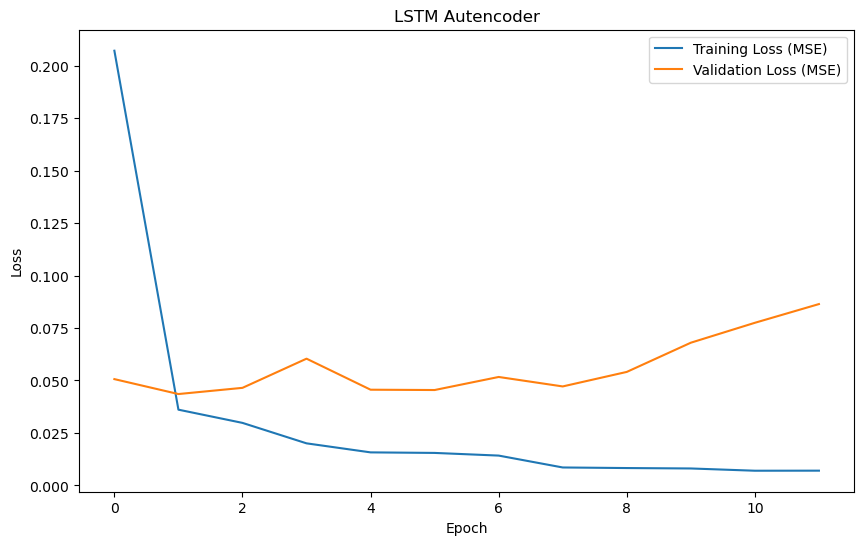

193/193 [==============================] - 1s 2ms/step
Threshold: 0.12602766530894716


In [216]:
train(True)

In [221]:
def test():
    """
    """
    df = getMixedData()
    X = df[["circ1.r_load.v", "circ1.r_load.i"]].astype(float).values
    
    model, scaler = loadModelAndScalar("lstm_autoencoder")
    
    X_scaled = scaler.transform(X)

    X_windows = create_sliding_windows(X_scaled, window_size, step=step_size)
    print(f"Testing windows shape: {X_windows.shape}")
    
   
   
    print("Autoencoder model loaded from 'lstm_autoencoder.h5'.")
    
    # Compute reconstruction errors
    reconstructed_test = model.predict(X_windows)
    test_errors = np.mean(np.power(X_windows - reconstructed_test, 2), axis=(1,2))

    # Detect anomalies
    anomaly_mask = test_errors > threshold
    print(f"Number of anomalies detected: {np.sum(anomaly_mask)} / {len(test_errors)}")
    
    # Retrieve 'Anomalous' Labels from DataFrame
    # Create corresponding window labels based on the original DataFrame
    df_windows = df.iloc[:len(X_windows)*step_size + window_size - 1].reset_index(drop=True)
    anomolous = getAnomalyMask(df_windows)
    anomolous = np.array(anomolous)
    
    # Assign each window a label: True if any point in the window is anomalous
    window_labels = []
    for i in range(len(X_windows)):
        window_start = i * step_size
        window_end = window_start + window_size
        if window_end > len(anomolous):
            window_end = len(anomolous)
        window_anomalies = anomolous[window_start:window_end]
        window_label = window_anomalies.any()  # True if any point in window is anomalous
        window_labels.append(window_label)
    
    window_labels = np.array(window_labels)
    
    # Evaluate Performance (Optional)
    # If you have true labels, compute ROC-AUC
    #auc_score = roc_auc_score(window_labels, test_errors)
  #  print(f"ROC-AUC Score: {auc_score:.4f}")
    
    # Plotting Reconstruction Error Histogram with Anomalies Highlighted
    normal_errors = test_errors[~anomaly_mask]
    anomalous_errors = test_errors[anomaly_mask]
    
 # plt.figure(figsize=(10, 6))
 # plt.hist(normal_errors, bins=50, alpha=0.7, label='Normal', color='blue', edgecolor='black')
 # plt.hist(anomalous_errors, bins=50, alpha=0.7, label='Anomalous', color='red', edgecolor='black')
 # plt.axvline(x=threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.2f}')
 # plt.xlabel("Reconstruction Error (MSE)")
 # plt.ylabel("Count")
 # plt.title("Histogram of Reconstruction Errors with Anomalies Highlighted")
 # plt.legend()
 # plt.show()
    
    # Enhanced Visualization with Seaborn
    error_df = pd.DataFrame({
        'Reconstruction_Error': test_errors,
        'Anomaly': anomaly_mask
    })

    tp_mask = anomaly_mask &  window_labels  # True Positive
    fp_mask = anomaly_mask & ~window_labels  # False Positive
    fn_mask = ~anomaly_mask & window_labels  # False Negative
    tn_mask = ~anomaly_mask & ~window_labels # True Negative
    
    tp_errors = test_errors[tp_mask]
    fp_errors = test_errors[fp_mask]
    fn_errors = test_errors[fn_mask]
    tn_errors = test_errors[tn_mask]

    plt.figure(figsize=(10,6))
    plt.axvline(x=threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.2f}')
    plt.hist(tn_errors, bins=50, alpha=0.6, label='TN', color='blue', edgecolor='black')
    plt.hist(tp_errors, bins=50, alpha=0.6, label='TP', color='green', edgecolor='black')
    plt.hist(fp_errors, bins=50, alpha=0.6, label='FP', color='orange', edgecolor='black')
    plt.hist(fn_errors, bins=50, alpha=0.6, label='FN', color='red', edgecolor='black')
    plt.yscale('log')
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Count")
    plt.title("Reconstruction Errors by Classification Outcome")
    plt.legend()
    plt.show()
    
   # plt.figure(figsize=(10, 6))
   # sns.histplot(
   #     data=error_df[~error_df['Anomaly']], 
   #     x='Reconstruction_Error', 
   #     bins=50, 
   #     color='blue', 
   #     label='Normal', 
   #     kde=True, 
   #     stat="density", 
   #     alpha=0.6
   # )
    #sns.histplot(
    #    data=error_df[error_df['Anomaly']], 
    #    x='Reconstruction_Error', 
    #    bins=50, 
    #    color='red', 
    #    label='Anomalous', 
    #    kde=True, 
    #    stat="density", 
    #    alpha=0.6
    #)
    #plt.axvline(x=threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.2f}')
    #plt.xlabel("Reconstruction Error (MSE)")
    #plt.ylabel("Density")
    #plt.title("Distribution of Reconstruction Errors with Anomalies Highlighted")
    #plt.legend()
    #plt.show()
    #
    ## Optional: Plot Reconstruction Errors Over Time with Anomalies Highlighted
    #plt.figure(figsize=(15, 6))
    #plt.plot(test_errors, label='Reconstruction Error', color='blue')
    #plt.axhline(y=threshold, color='green', linestyle='--', linewidth=2, label='Threshold')
    #plt.scatter(
    #    np.where(anomaly_mask)[0], 
    #    test_errors[anomaly_mask], 
    #    color='red', 
    #    label='Anomalies'
    #)
    #plt.xlabel("Window Index")
    #plt.ylabel("Reconstruction Error (MSE)")
    #plt.title("Reconstruction Errors Over Time with Anomalies Highlighted")
    #plt.legend()
    #plt.show()


Testing windows shape: (2157, 6, 2)
Autoencoder model loaded from 'lstm_autoencoder.h5'.
68/68 [==============================] - 0s 2ms/step
Number of anomalies detected: 1566 / 2157


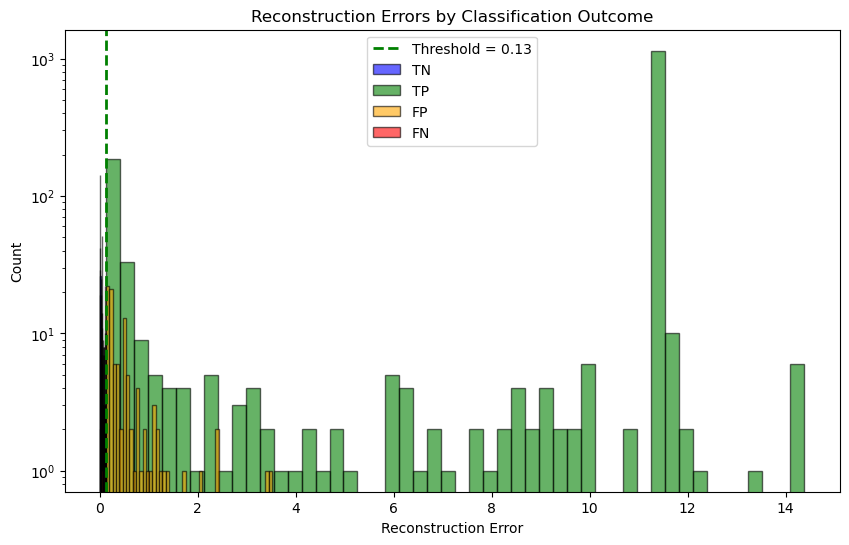

In [222]:
test()